# Protocole temporel et modèle hybride

Le protocole des notebooks 02 et 03 laisse le modèle voir le futur.

In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"

import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from implicit.als import AlternatingLeastSquares
from implicit.nearest_neighbours import bm25_weight
from sklearn.decomposition import PCA

sys.path.insert(0, "../src")
sys.path.insert(0, "../azure_function")
import recommender
from utils import N_RECO, SEED, load_articles_metadata, load_clicks, load_embeddings, sample_eval_users, temporal_split

MIN = 60_000
HEURE = 3_600_000

clicks = load_clicks("../data")[["user_id", "session_id", "click_article_id", "click_timestamp"]].astype("int64")
articles = load_articles_metadata("../data")
created = articles["created_at_ts"].to_numpy()

emb50 = PCA(n_components=50, random_state=SEED).fit_transform(load_embeddings("../data")).astype(np.float32)
emb50 = emb50 / np.linalg.norm(emb50, axis=1, keepdims=True)

## 1. Fuite

Avec le dernier clic caché, le train contient des clics postérieurs au clic à deviner.

In [2]:
train, test = temporal_split(clicks)
test_eval = test.set_index("user_id").loc[sample_eval_users(test, 5000, SEED)]
ts_train = np.sort(train["click_timestamp"].to_numpy())
part_futur = 1 - np.searchsorted(ts_train, test_eval["click_timestamp"].to_numpy(), side="right") / len(ts_train)
print(f"Part des clics du train postérieurs au clic à deviner : {np.median(part_futur):.0%} en médiane")

Part des clics du train postérieurs au clic à deviner : 25% en médiane


## 2. Coupure par date

Train = clics avant le 13/10/2017 03:00 UTC, test = les 4 jours suivants. Cibles : 4 000 clics d'utilisateurs connus tirés au hasard et le premier clic de 4 000 nouveaux utilisateurs.

In [3]:
coupure = int(pd.Timestamp("2017-10-13 03:00", tz="UTC").timestamp() * 1000)
fin = int(pd.Timestamp("2017-10-17 03:00", tz="UTC").timestamp() * 1000)
ts_all = clicks["click_timestamp"].to_numpy()
art_all = clicks["click_article_id"].to_numpy()
deja_lu = clicks.duplicated(["user_id", "click_article_id"])
train_t = clicks[ts_all < coupure]
test_t = clicks[(ts_all >= coupure) & (ts_all < fin) & ~deja_lu]

connu = test_t["user_id"].isin(train_t["user_id"].unique())
cibles = pd.concat([
    test_t[connu].sample(4000, random_state=SEED).assign(population="connus"),
    test_t[~connu].groupby("user_id").head(1).sample(4000, random_state=SEED).assign(population="nouveaux"),
]).rename(columns={"click_timestamp": "t", "click_article_id": "article"})
cibles = cibles[["population", "user_id", "t", "article"]].sort_values("t").reset_index(drop=True)

clics_u = clicks.sort_values(["user_id", "click_timestamp"], kind="stable")
users_u, debuts = np.unique(clics_u["user_id"].to_numpy(), return_index=True)
hist_art = dict(zip(users_u, np.split(clics_u["click_article_id"].to_numpy(), debuts[1:])))
hist_ts = dict(zip(users_u, np.split(clics_u["click_timestamp"].to_numpy(), debuts[1:])))


def historique(user, t):
    n = np.searchsorted(hist_ts[user], t)
    return hist_art[user][:n], hist_ts[user][:n]


print("Clics train :", len(train_t), "| clics test :", len(test_t), "| cibles :", len(cibles))
print(f"Articles lus pendant le test et parus après la coupure : {(created[cibles['article']] > coupure).mean():.1%}")

Clics train : 2430428 | clics test : 547870 | cibles : 8000
Articles lus pendant le test et parus après la coupure : 83.2%


## 3. Évaluation

Chaque modèle renvoie 5 articles (ni déjà lus, ni pas encore publiés) ; hit rate @ 5 et MRR @ 5 par population.

In [4]:
resultats = {}


def filtrer(ids, t, lus):
    lus = set(lus)
    return [int(a) for a in ids if created[a] <= t and a not in lus][:N_RECO]


def noter(nom, recos):
    resultats[nom] = {}
    for pop in ["connus", "nouveaux"]:
        masque = (cibles["population"] == pop).to_numpy()
        rangs = np.array([r.index(a) + 1 if a in r else 0 for r, a, m in zip(recos, cibles["article"], masque) if m])
        hit, mrr = np.mean(rangs > 0), np.sum(1 / rangs[rangs > 0]) / len(rangs)
        resultats[nom][pop] = {"hit_rate_at_5": round(float(hit), 4), "mrr_at_5": round(float(mrr), 4)}
    print(nom, resultats[nom])


def evaluer(nom, reco_fn):
    noter(nom, [reco_fn(c.user_id, c.t, *historique(c.user_id, c.t)) for c in cibles.itertuples()])

## 4. Modèles de référence

Popularité depuis le début, tendance des 30 dernières minutes, content-based limité aux articles de moins de 24 h, ALS + BM25 entraîné une fois sur le train.

In [5]:
top_pop = train_t["click_article_id"].value_counts().index[:50].to_numpy()


def popularite(user, t, lus, ts):
    return filtrer(top_pop, t, lus)


def tendance_30min(user, t, lus, ts):
    b = t - (t - coupure) % (30 * MIN)
    lo, hi = np.searchsorted(ts_all, [b - 30 * MIN, b])
    ids, n = np.unique(art_all[lo:hi], return_counts=True)
    return filtrer(ids[np.argsort(-n, kind="stable")[:50]], t, lus)


evaluer("popularite", popularite)
evaluer("tendance_30min", tendance_30min)

popularite {'connus': {'hit_rate_at_5': 0.0005, 'mrr_at_5': 0.0003}, 'nouveaux': {'hit_rate_at_5': 0.0, 'mrr_at_5': 0.0}}


tendance_30min {'connus': {'hit_rate_at_5': 0.371, 'mrr_at_5': 0.2041}, 'nouveaux': {'hit_rate_at_5': 0.4675, 'mrr_at_5': 0.2697}}


In [6]:
ordre = np.argsort(created, kind="stable")


def cb_frais_24h(user, t, lus, ts):
    if len(lus) == 0:
        return []
    lo, hi = np.searchsorted(created[ordre], [t - 24 * HEURE, t], side="right")
    candidats = ordre[lo:hi]
    scores = emb50[candidats] @ emb50[np.unique(lus)].mean(axis=0)
    return filtrer(candidats[np.argsort(-scores)[:50]], t, lus)


evaluer("cb_frais_24h", cb_frais_24h)

cb_frais_24h {'connus': {'hit_rate_at_5': 0.0622, 'mrr_at_5': 0.0313}, 'nouveaux': {'hit_rate_at_5': 0.0, 'mrr_at_5': 0.0}}


In [7]:
users_als = np.sort(train_t["user_id"].unique())
lignes = np.searchsorted(users_als, train_t["user_id"].to_numpy())
mat = sp.csr_matrix((np.ones(len(train_t), dtype=np.float32), (lignes, train_t["click_article_id"].to_numpy())),
                    shape=(len(users_als), len(articles)))
mat_bm25 = bm25_weight(mat, K1=100, B=0.8).tocsr().astype(np.float32)
als = AlternatingLeastSquares(factors=64, regularization=0.05, iterations=15, random_state=SEED)
als.fit(mat_bm25, show_progress=False)


def als_bm25(user, t, lus, ts):
    i = np.searchsorted(users_als, user)
    if i == len(users_als) or users_als[i] != user:
        return []
    ids, _ = als.recommend(i, mat_bm25[i], N=20, filter_already_liked_items=True)
    return filtrer(ids, t, lus)


evaluer("als_bm25", als_bm25)

als_bm25 {'connus': {'hit_rate_at_5': 0.0005, 'mrr_at_5': 0.0001}, 'nouveaux': {'hit_rate_at_5': 0.0, 'mrr_at_5': 0.0}}


## 5. Modèle hybride (celui de l'Azure Function)

Score = tendance + 0,7 × co-visitation + 0,008 × contenu (co-visitation seulement si le dernier clic date de 30 min au plus ; sans historique : tendance seule). Poids choisis lors d'une première étude sur les clics du 9 au 12/10, avant la coupure.

Pendant le test, l'instantané est reconstruit toutes les 30 minutes (15 dans l'architecture cible) ; les clics faits depuis sont transmis à la requête, comme le paramètre recent.

In [8]:
clicks_dict = {c: clicks[c].to_numpy() for c in ["user_id", "session_id", "click_article_id", "click_timestamp"]}
recos = [None] * len(cibles)
for b in range(coupure, fin, 30 * MIN):
    snap = recommender.build_snapshot(clicks_dict, np.arange(len(articles)), created, emb50, t_ref=b)
    for c in cibles[(cibles["t"] >= b) & (cibles["t"] < b + 30 * MIN)].itertuples():
        lus, ts = historique(c.user_id, c.t)
        recos[c.Index], _ = recommender.recommend(snap, c.user_id, N_RECO, recent_items=lus[ts >= b], now_ms=c.t)

noter("hybride", recos)

hybride {'connus': {'hit_rate_at_5': 0.4263, 'mrr_at_5': 0.2477}, 'nouveaux': {'hit_rate_at_5': 0.4768, 'mrr_at_5': 0.2703}}


## 6. Résultats

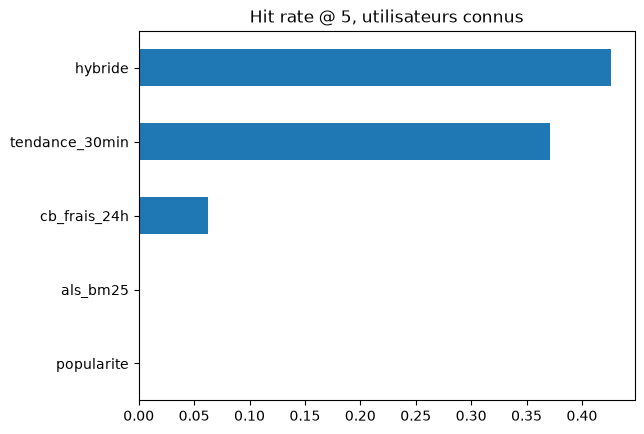

,connus,nouveaux
popularite,0.0005,0.0000
tendance_30min,0.3710,0.4675
cb_frais_24h,0.0622,0.0000
als_bm25,0.0005,0.0000
hybride,0.4263,0.4768


In [9]:
tableau = pd.DataFrame({pop: {nom: r[pop]["hit_rate_at_5"] for nom, r in resultats.items()} for pop in ["connus", "nouveaux"]})
tableau["connus"].sort_values().plot.barh(title="Hit rate @ 5, utilisateurs connus")
plt.show()

with open("../results/metrics_04.json", "w", encoding="utf-8") as f:
    json.dump({pop: {nom: r[pop] for nom, r in resultats.items()} for pop in ["connus", "nouveaux"]}, f, indent=2)

tableau

## Conclusion

- Le premier protocole voyait le futur : en médiane 25 % des clics du train étaient postérieurs au clic à deviner.
- 83,2 % des articles lus pendant le test sont parus après la coupure : les modèles entraînés une fois (popularité, ALS) s'effondrent.
- Modèle retenu : l'hybride, 0,4263 pour les utilisateurs connus et 0,4768 pour les nouveaux, contre 0,3710 et 0,4675 pour la tendance 30 min.